In [331]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

In [332]:
df=pd.read_csv(r'C:\xampp816\htdocs\personal-dev\py-ds\ML\loan_approval\loan_approval_dataset.csv')
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [333]:
df.duplicated().sum()

np.int64(0)

In [334]:
df.isna().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [335]:
df=df.drop(columns='loan_id')

In [336]:
# for i in df:
#     print(df[i].value_counts())
df[' loan_status'].value_counts()

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [337]:
df.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [338]:
df.columns = df.columns.str.strip()
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [339]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [340]:
df_copy = df.copy()

In [341]:
df.dtypes

no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

In [342]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder

In [343]:
label=[]
for i in df:
    if df[i].nunique()==2 and df[i].dtype=='object':
        label.append(i)
label

['education', 'self_employed', 'loan_status']

In [344]:
label_dict={}
for i in label:
    if i != 'loan_status':
        label_dict[i]=LabelEncoder()
        df[i]=label_dict[i].fit_transform(df[i])
label_dict

{'education': LabelEncoder(), 'self_employed': LabelEncoder()}

In [345]:
ordinal = OrdinalEncoder(categories=[[" Rejected", " Approved"]])
df['loan_status'] = ordinal.fit_transform(df[['loan_status']])

In [346]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1.0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0.0
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0.0
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0.0
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,0,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0.0
4265,0,1,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1.0
4266,2,1,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0.0
4267,1,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1.0


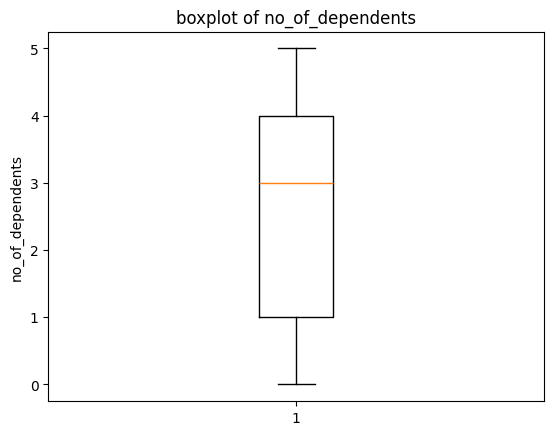

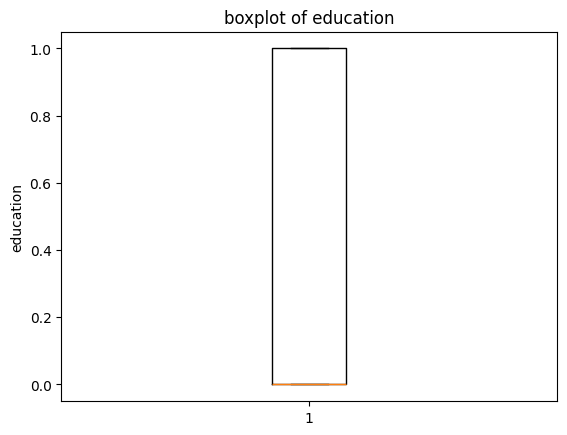

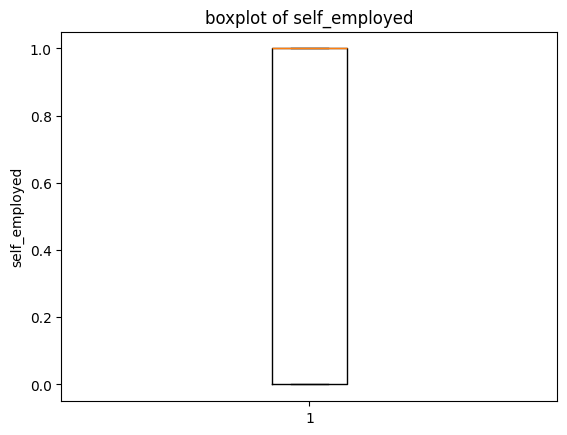

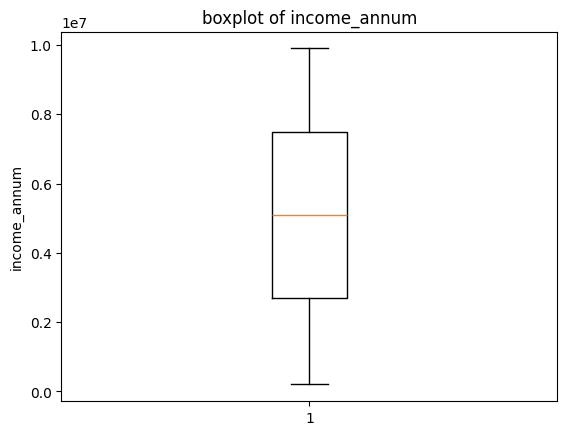

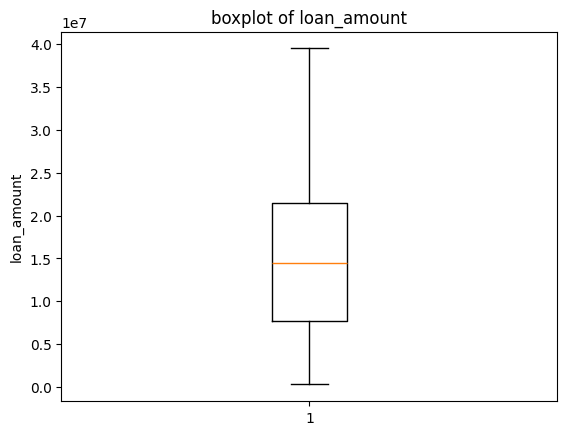

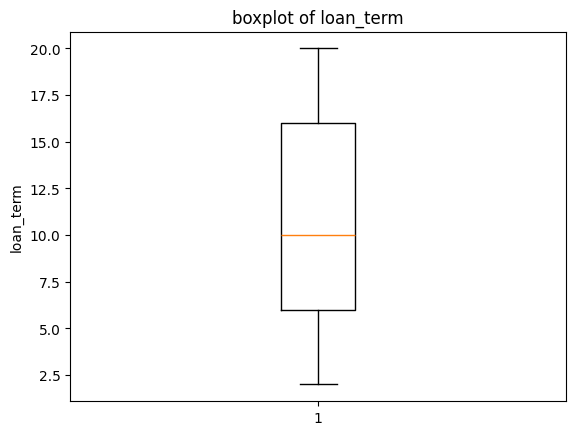

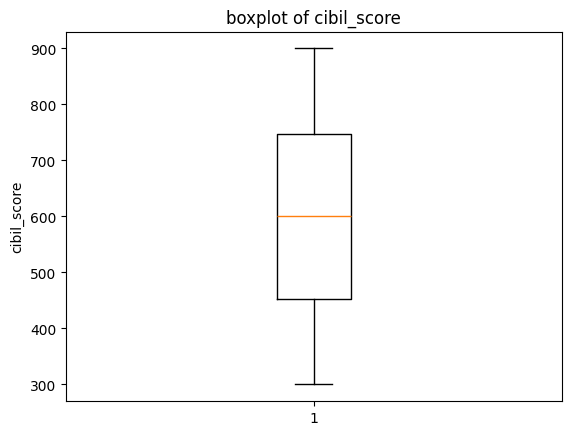

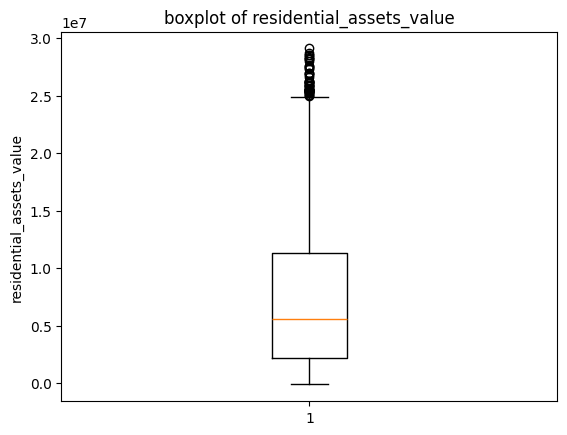

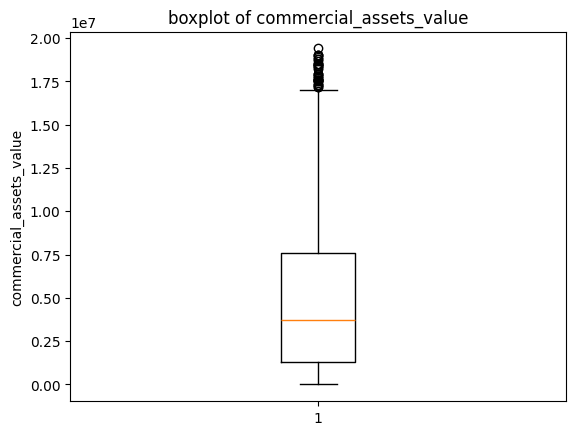

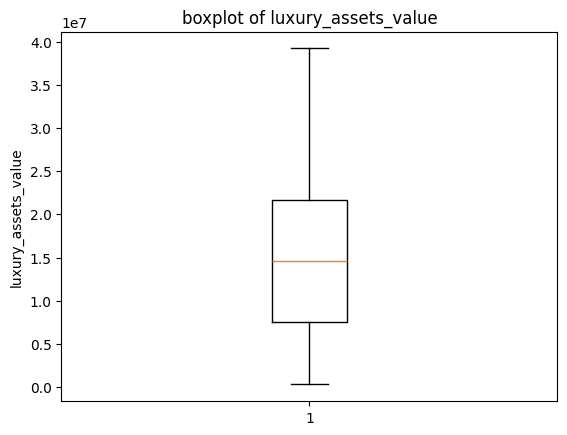

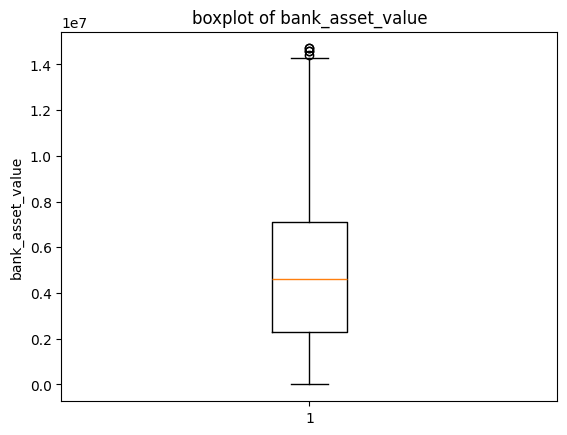

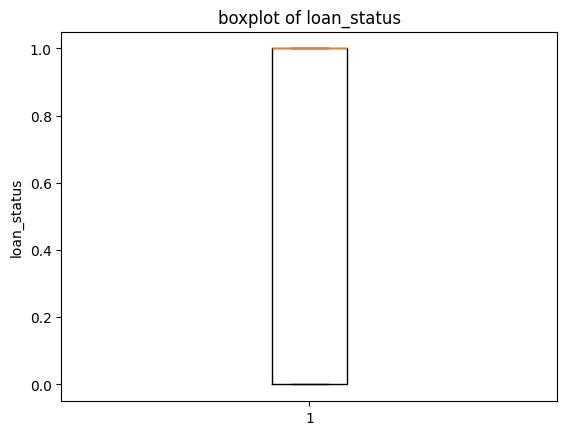

In [347]:
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        plt.boxplot(df[i])
        plt.title(f'boxplot of {i}')
        plt.ylabel(i)
        plt.show()

<Axes: >

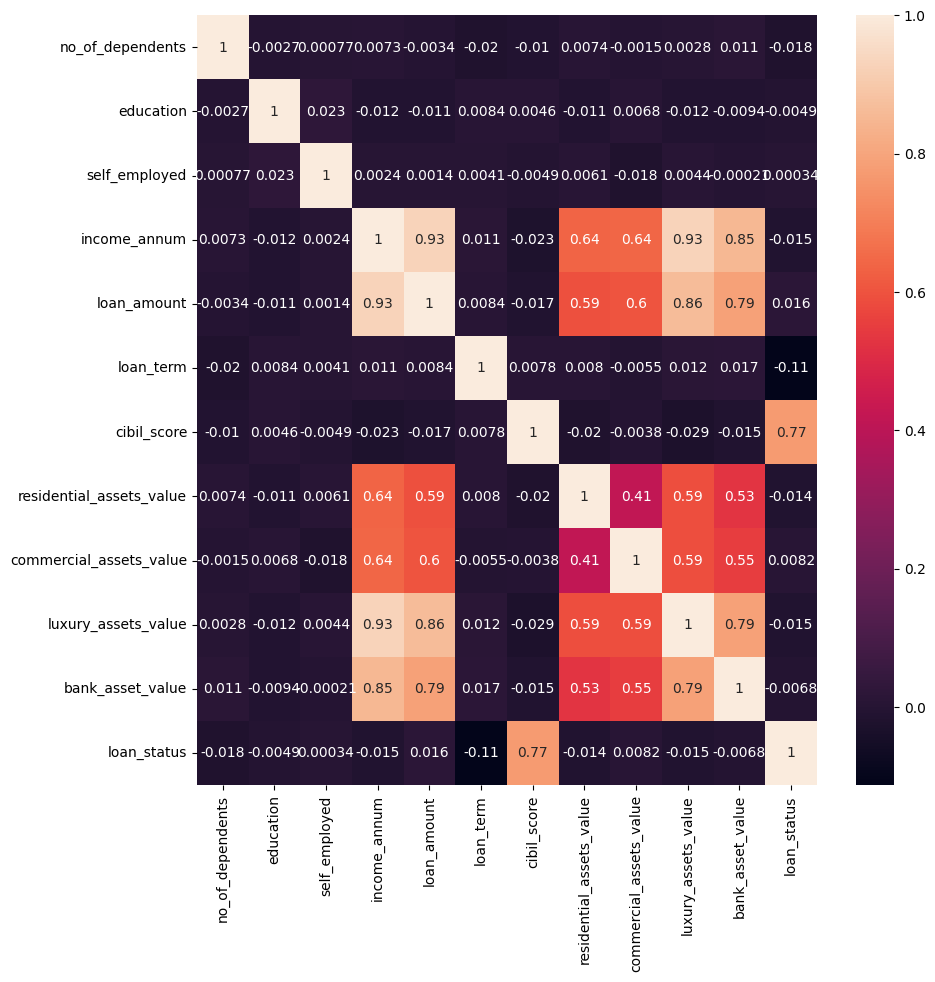

In [348]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [349]:
df.dtypes

no_of_dependents              int64
education                     int64
self_employed                 int64
income_annum                  int64
loan_amount                   int64
loan_term                     int64
cibil_score                   int64
residential_assets_value      int64
commercial_assets_value       int64
luxury_assets_value           int64
bank_asset_value              int64
loan_status                 float64
dtype: object

In [350]:
x=df.drop(columns=['loan_status'])
y=df['loan_status']

In [351]:
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()
x_scaled = minmax.fit_transform(x)

In [352]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=5)

KNeighborsClassifier()
----------------------------
92.03747072599532
[[443  52]
 [ 50 736]]
              precision    recall  f1-score   support

         0.0       0.90      0.89      0.90       495
         1.0       0.93      0.94      0.94       786

    accuracy                           0.92      1281
   macro avg       0.92      0.92      0.92      1281
weighted avg       0.92      0.92      0.92      1281



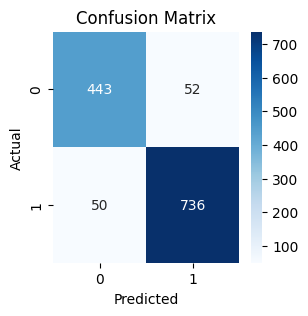


SVC()
----------------------------
94.30132708821233
[[461  34]
 [ 39 747]]
              precision    recall  f1-score   support

         0.0       0.92      0.93      0.93       495
         1.0       0.96      0.95      0.95       786

    accuracy                           0.94      1281
   macro avg       0.94      0.94      0.94      1281
weighted avg       0.94      0.94      0.94      1281



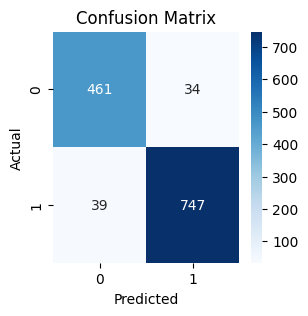


SVC(C=1000)
----------------------------
95.23809523809523
[[462  33]
 [ 28 758]]
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94       495
         1.0       0.96      0.96      0.96       786

    accuracy                           0.95      1281
   macro avg       0.95      0.95      0.95      1281
weighted avg       0.95      0.95      0.95      1281



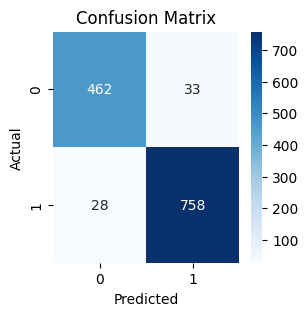


MultinomialNB()
----------------------------
63.70023419203748
[[ 32 463]
 [  2 784]]
              precision    recall  f1-score   support

         0.0       0.94      0.06      0.12       495
         1.0       0.63      1.00      0.77       786

    accuracy                           0.64      1281
   macro avg       0.78      0.53      0.45      1281
weighted avg       0.75      0.64      0.52      1281



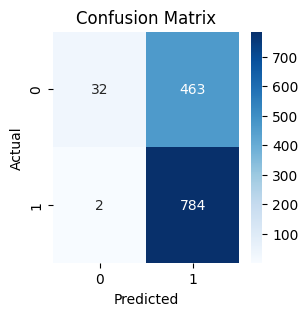


GaussianNB()
----------------------------
93.44262295081968
[[453  42]
 [ 42 744]]
              precision    recall  f1-score   support

         0.0       0.92      0.92      0.92       495
         1.0       0.95      0.95      0.95       786

    accuracy                           0.93      1281
   macro avg       0.93      0.93      0.93      1281
weighted avg       0.93      0.93      0.93      1281



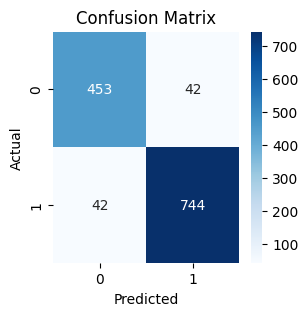

In [353]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

models=[KNeighborsClassifier(), SVC(), SVC(C=1000), MultinomialNB(), GaussianNB()]
for model in models:
    model.fit(x_train, y_train)
    y_pred=model.predict(x_test)
    print(model)
    print("----------------------------")
    print(accuracy_score(y_test, y_pred)*100)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    plt.figure(figsize=(3,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), fmt='d', cmap='Blues', annot=True)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print()

In [354]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
x_over_s, y_over_s = smote.fit_resample(x_scaled, y)

In [355]:
pd.DataFrame(x_over_s).duplicated().sum()

np.int64(0)

KNeighborsClassifier()
----------------------------
92.03747072599532
[[443  52]
 [ 50 736]]
              precision    recall  f1-score   support

         0.0       0.90      0.89      0.90       495
         1.0       0.93      0.94      0.94       786

    accuracy                           0.92      1281
   macro avg       0.92      0.92      0.92      1281
weighted avg       0.92      0.92      0.92      1281



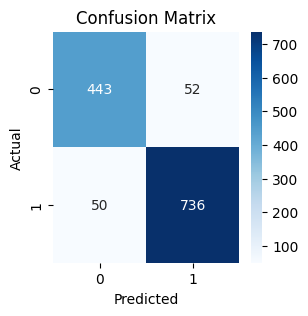


SVC()
----------------------------
94.30132708821233
[[461  34]
 [ 39 747]]
              precision    recall  f1-score   support

         0.0       0.92      0.93      0.93       495
         1.0       0.96      0.95      0.95       786

    accuracy                           0.94      1281
   macro avg       0.94      0.94      0.94      1281
weighted avg       0.94      0.94      0.94      1281



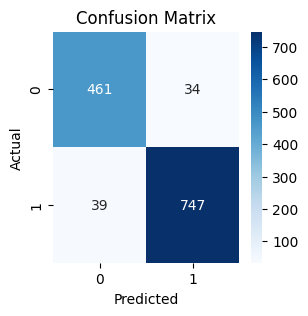


SVC(C=1000)
----------------------------
95.23809523809523
[[462  33]
 [ 28 758]]
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94       495
         1.0       0.96      0.96      0.96       786

    accuracy                           0.95      1281
   macro avg       0.95      0.95      0.95      1281
weighted avg       0.95      0.95      0.95      1281



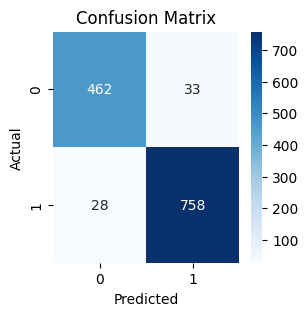


MultinomialNB()
----------------------------
63.70023419203748
[[ 32 463]
 [  2 784]]
              precision    recall  f1-score   support

         0.0       0.94      0.06      0.12       495
         1.0       0.63      1.00      0.77       786

    accuracy                           0.64      1281
   macro avg       0.78      0.53      0.45      1281
weighted avg       0.75      0.64      0.52      1281



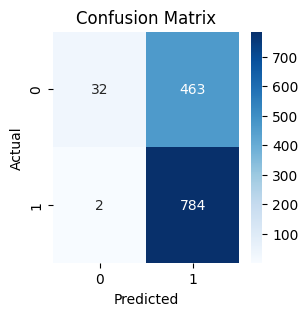


GaussianNB()
----------------------------
93.44262295081968
[[453  42]
 [ 42 744]]
              precision    recall  f1-score   support

         0.0       0.92      0.92      0.92       495
         1.0       0.95      0.95      0.95       786

    accuracy                           0.93      1281
   macro avg       0.93      0.93      0.93      1281
weighted avg       0.93      0.93      0.93      1281



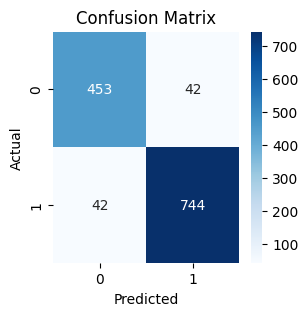

In [356]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

models=[KNeighborsClassifier(), SVC(), SVC(C=1000), MultinomialNB(), GaussianNB()]
for model in models:
    model.fit(x_train, y_train)
    y_pred=model.predict(x_test)
    print(model)
    print("----------------------------")
    print(accuracy_score(y_test, y_pred)*100)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    plt.figure(figsize=(3,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), fmt='d', cmap='Blues', annot=True)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print()

K-fold cross validation

In [357]:
from sklearn.model_selection import cross_val_score
print('KNeighborsClassifier : ', cross_val_score(KNeighborsClassifier(),x_scaled,y,cv=6).mean()*100)
print('SVC : ', cross_val_score(SVC(),x_scaled,y,cv=6).mean()*100)
print('SVC(C=1000) : ', cross_val_score(SVC(C=1000),x_scaled,y,cv=6).mean()*100)
print('MultinomialNB : ', cross_val_score(MultinomialNB(),x_scaled,y,cv=6).mean()*100)
print('GaussianNB : ', cross_val_score(GaussianNB(),x_scaled,y,cv=6).mean()*100)

KNeighborsClassifier :  90.51291371018296
SVC :  93.58173064260393
SVC(C=1000) :  94.19054241270142
MultinomialNB :  64.53490362784916
GaussianNB :  93.3004037674426


In [358]:
from sklearn.model_selection import cross_val_score
print('KNeighborsClassifier : ', cross_val_score(KNeighborsClassifier(),x_scaled,y,cv=10).mean()*100)
print('SVC : ', cross_val_score(SVC(),x_scaled,y,cv=10).mean()*100)
print('SVC(C=1000) : ', cross_val_score(SVC(C=1000),x_scaled,y,cv=10).mean()*100)
print('MultinomialNB : ', cross_val_score(MultinomialNB(),x_scaled,y,cv=10).mean()*100)
print('GaussianNB : ', cross_val_score(GaussianNB(),x_scaled,y,cv=10).mean()*100)

KNeighborsClassifier :  90.6068652351266
SVC :  93.72233400402415
SVC(C=1000) :  94.72979956240172
MultinomialNB :  64.53502435377291
GaussianNB :  93.37077107453466
